<a href="https://colab.research.google.com/github/Denzzo-ov/Simulative-1-semester-project-/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_1_%D1%81%D0%B5%D0%BC%D0%B5%D1%81%D1%82%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Анализ Индийского рынка автомобилей с пробегом (данные на 2023 год)

#### Импортируем необходимые библиотеки

In [24]:
import math
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gdown

#### Импортируем файл с данными из Google Drive

In [25]:
url = 'https://drive.google.com/uc?id=1GC0F4FgnF-u0l-prTyeSuaCJ6eLIeXtr'
output_path = 'indian_cars.csv'
gdown.download(url, output_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1GC0F4FgnF-u0l-prTyeSuaCJ6eLIeXtr
To: /content/indian_cars.csv
100%|██████████| 2.69M/2.69M [00:00<00:00, 164MB/s]


'indian_cars.csv'

In [26]:
# сохраним файл в форме датафрейм
df = pd.read_csv('indian_cars.csv', sep = ',')
pd.set_option('display.float_format', '{:.2f}'.format)

#### Предварительное знакомство со структурой данных

- full_name — название автомобиля с указанием модели и года выпуска;
- resale_price — цена перепродажи автомобиля в рупиях с указанием единицы измерения: Lakh — 100 000 рупий, Crore — 10 000 000 рупий;
- registered_year — год постановки автомобиля на учет;
- engine_capacity — объем двигателя в сс (кубических сантиметрах);
- insurance — тип страхования, доступного для автомобиля;
- transmission_type — тип коробки передач;
- kms_driven — пробег;
- owner_type — порядковый номер владельца автомобиля;
- fuel_type — тип топлива (бензин или дизель);
- max_power — максимальная мощность автомобиля в лошадиных силах;
- seats — количество посадочных мест;
- mileage — расход топлива;
- body_type — тип кузова (хэтчбек или седан);
- city — город продажи.

Прдварительная обработка данных: проверка на пропуски

In [27]:
# проверим данные на полноту
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16747 entries, 0 to 16746
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   full_name          16747 non-null  object 
 1   resale_price       16747 non-null  object 
 2   registered_year    16700 non-null  object 
 3   engine_capacity    16747 non-null  object 
 4   insurance          16740 non-null  object 
 5   transmission_type  16747 non-null  object 
 6   kms_driven         16747 non-null  object 
 7   owner_type         16706 non-null  object 
 8   fuel_type          16747 non-null  object 
 9   max_power          16747 non-null  object 
 10  seats              16746 non-null  float64
 11  mileage            16336 non-null  object 
 12  body_type          16747 non-null  object 
 13  city               16747 non-null  object 
dtypes: float64(1), object(13)
memory usage: 1.8+ MB


In [28]:
df.isnull().sum()

,0
full_name,0
resale_price,0
registered_year,47
engine_capacity,0
insurance,7
transmission_type,0
kms_driven,0
owner_type,41
fuel_type,0
max_power,0


In [29]:
# Пропуски выявлены в столбцах registered_year, insurance, owner_type, seats.
# Данные показатели не являются значимыми для анализа поэтому оставим их.

Предварительная обработка данных: проверка на дубли

In [30]:
df_clean = (df.copy()).drop_duplicates()
print(f'Количество в df: {df.shape[0]}')
print(f'Количество в df_clean: {df_clean.shape[0]}')
print(f'Удалено дублей: {df.shape[0] - df_clean.shape[0]}')

Количество в df: 16747
Количество в df_clean: 16560
Удалено дублей: 187


In [31]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16560 entries, 0 to 16746
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   full_name          16560 non-null  object 
 1   resale_price       16560 non-null  object 
 2   registered_year    16513 non-null  object 
 3   engine_capacity    16560 non-null  object 
 4   insurance          16553 non-null  object 
 5   transmission_type  16560 non-null  object 
 6   kms_driven         16560 non-null  object 
 7   owner_type         16519 non-null  object 
 8   fuel_type          16560 non-null  object 
 9   max_power          16560 non-null  object 
 10  seats              16559 non-null  float64
 11  mileage            16153 non-null  object 
 12  body_type          16560 non-null  object 
 13  city               16560 non-null  object 
dtypes: float64(1), object(13)
memory usage: 1.9+ MB


Введем ограничение для целей импорта в РФ:
- возраст автомобиля до 6 лет
- объем двигателя от 1000 кубиков  

In [32]:
# извлекаем год производства из переменной full name
df_clean['prod_year'] = (df_clean['full_name'].apply(lambda x: x.split()[0])).astype(int)

# извлекаем V двигателя в числовой форме
df_clean['engine_capacity_int'] = df_clean['engine_capacity'].apply(lambda x: x.split()[0]).astype(int)

In [33]:
# фильтр по году и двигателю
df_f = (df_clean.copy()).query('engine_capacity_int >= 1000 and prod_year >= 2017')
df_f = df_f.reset_index(drop=True)
df_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7570 entries, 0 to 7569
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   full_name            7570 non-null   object 
 1   resale_price         7570 non-null   object 
 2   registered_year      7554 non-null   object 
 3   engine_capacity      7570 non-null   object 
 4   insurance            7565 non-null   object 
 5   transmission_type    7570 non-null   object 
 6   kms_driven           7570 non-null   object 
 7   owner_type           7554 non-null   object 
 8   fuel_type            7570 non-null   object 
 9   max_power            7570 non-null   object 
 10  seats                7569 non-null   float64
 11  mileage              7196 non-null   object 
 12  body_type            7570 non-null   object 
 13  city                 7570 non-null   object 
 14  prod_year            7570 non-null   int64  
 15  engine_capacity_int  7570 non-null   i

#### Добавим новые показатели в датасет

In [35]:
# извлекаем название модели автомобиля
df_f['model_name'] = df_f['full_name'].apply(lambda x: x[5:]).astype(str)

In [36]:
# извлекаем бренд автомобиля
brands = {
    'Audi', 'BMW', 'Bentley', 'Chevrolet', 'Citroen', 'Datsun',
    'Fiat', 'Force', 'Ford', 'Honda', 'Hyundai', 'Isuzu',
    'Jaguar', 'Jeep', 'Kia', 'Land Rover', 'Lexus', 'MG',
    'Mahindra', 'Maruti', 'Mercedes-Benz', 'Mini', 'Mitsubishi',
    'Nissan', 'Porsche', 'Renault', 'Skoda', 'Tata', 'Toyota',
    'Volkswagen', 'Volvo'
}

# используем функцию, чтобы получить полное наименование бренда (в случае названия из 2-х слов)
def extract_brand(text, brands):
    text_lower = text.lower()
    for brand in brands:
        if brand.lower() in text_lower:
            return brand
    return None

df_f['brand_name'] = df_f['full_name'].apply(lambda x: extract_brand(x, brands)).astype(str)

In [37]:
# Проверяем, что названия верно заполнились
brands = set(df_f['brand_name'])

{'Audi',
 'BMW',
 'Chevrolet',
 'Citroen',
 'Datsun',
 'Fiat',
 'Force',
 'Ford',
 'Honda',
 'Hyundai',
 'Isuzu',
 'Jaguar',
 'Jeep',
 'Kia',
 'Land Rover',
 'Lexus',
 'MG',
 'Mahindra',
 'Maruti',
 'Mercedes-Benz',
 'Mini',
 'Mitsubishi',
 'Nissan',
 'Porsche',
 'Renault',
 'Skoda',
 'Tata',
 'Toyota',
 'Volkswagen',
 'Volvo'}

Добавим цену автомобилей в рублях

In [38]:
# Обновим индексы, так как мы не планируем возвращаться к полному датасету
df_f= df_f.reset_index(drop=1)

# Извлечем середину из столбца resale_price (стоимость без учета Lakh_ и Crore). Затем переведен полученные строки в числа
df_f['resale_price_num']=df_f['resale_price'].apply(lambda x: x.split(' ')[1])
df_f['resale_price_num']=df_f['resale_price_num'].astype('float')

# Достаем конец из resale_price (Lakh_ или Crore)
df_f['resale_price_cat']=df_f['resale_price'].apply(lambda x: x.split(' ')[2])

# посчитаем мультипликатор
df_f['multiplier'] = df_f['resale_price_cat'].apply(lambda x: 10000000 if x == 'Crore' else 100000)

# Конвертируем в рубли по текущему курсу
df_f['resale_price_rub']=df_f['resale_price_num']*df_f['multiplier']*1.16

#### Проанализируем выборку в нескольких разрезах

Цены автомобилей

,prod_year,mean
0,2017,1170610.20
1,2018,1246281.03
2,2019,1455196.37
3,2020,1728747.23
4,2021,1761155.35
5,2022,2041379.34
6,2023,3131819.22


Text(0, 0.5, 'Цена')

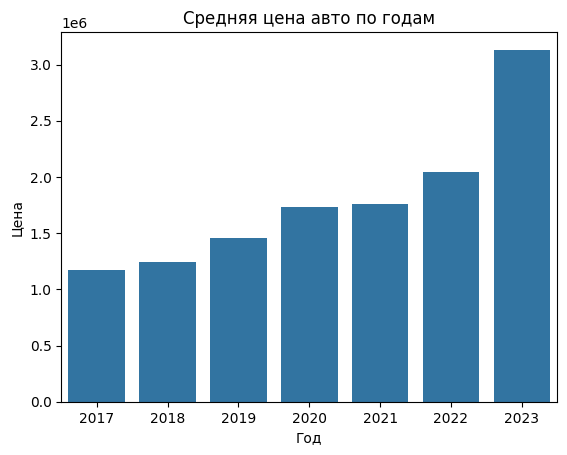

In [39]:
# Агрегируем значения по году
df_group_prod_year = round(df_f.groupby('prod_year')['resale_price_rub'].agg(['mean']),2)

# Строим график. Не забываем создать индексы, чтобы мы могли задать горизонтальную ось
df_group_prod_year=(df_group_prod_year.reset_index())
display(df_group_prod_year)

sns.barplot(df_group_prod_year, x='prod_year',y='mean')
plt.title('Средняя цена авто по годам')
plt.xlabel('Год')
plt.ylabel('Цена')

Распределение автомобилей по типу топлива

Text(0, 0.5, 'Количество автомобилей')

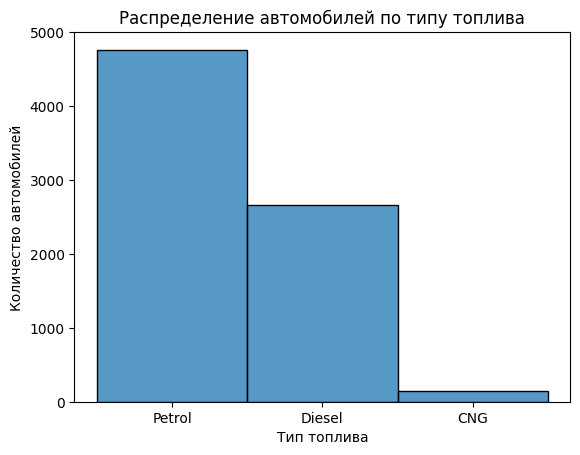

In [41]:
# строим гистограмму
sns.histplot(data = df_f, x='fuel_type')
# Добавление заголовка и подписей осей
plt.title('Распределение автомобилей по типу топлива')
plt.xlabel('Тип топлива')
plt.ylabel('Количество автомобилей')

Распределение автомобилей по объему двигателя

Text(0, 0.5, 'Количество автомобилей')

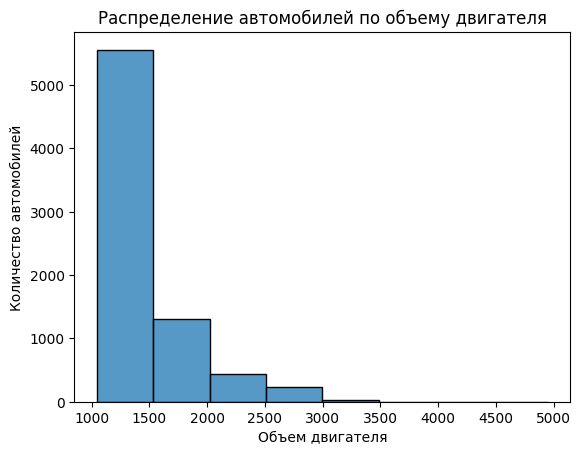

In [42]:
# строим гистограмму
sns.histplot(data = df_f, x='engine_capacity_int', binwidth= 500)

# Добавление заголовка и подписей осей
plt.title('Распределение автомобилей по объему двигателя')
plt.xlabel('Объем двигателя')
plt.ylabel('Количество автомобилей')

In [43]:
# напишем функцию для определения категории авто объему двигателя
def engine_cat(x):
    if x >= 2500:
        return 'крупнолитражный'
    elif 1600 <= x < 2500:
        return 'среднелитражный'
    else:
        return 'малолитражный'

In [44]:
# определим категорию двигателя
df_f['engine_cat'] = df_f['engine_capacity_int'].apply(lambda x: engine_cat(x))

In [45]:
display(df_f['engine_cat'].value_counts(normalize=True))

,proportion
engine_cat,
малолитражный,0.78
среднелитражный,0.18
крупнолитражный,0.04


Распределение авто по типу кузова

,proportion
body_type,
SUV,0.38
Hatchback,0.30
Sedan,0.26
MUV,0.05
Minivans,0.01
Pickup,0.00
Coupe,0.00
Wagon,0.00


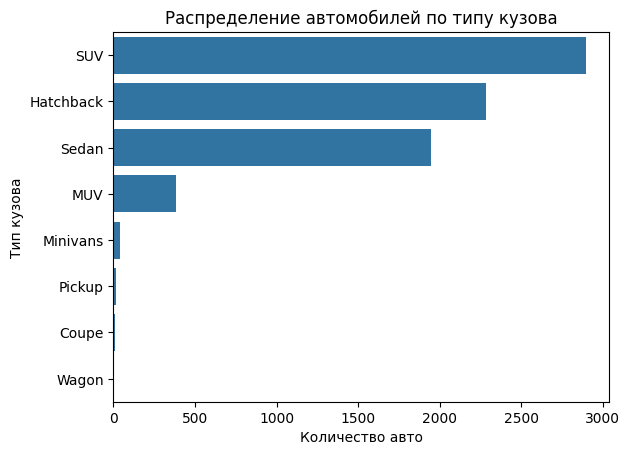

In [46]:
# порядок сортировки для графика
order = df_f['body_type'].value_counts().index

# строим гистограмму
sns.countplot(data = df_f, y='body_type', order =order)
# Добавление заголовка и подписей осей
plt.title('Распределение автомобилей по типу кузова')
plt.xlabel('Количество авто')
plt.ylabel('Тип кузова')

# таблица с долями
car_body = df_f['body_type'].value_counts(normalize=True)
display(car_body)

Распределение автомобилей по брендам

Text(0, 0.5, 'Бренд')

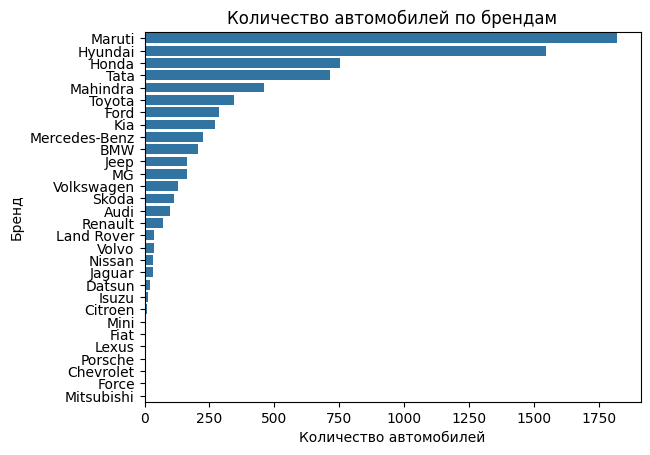

In [47]:
# Получение порядка брендов по убыванию количества
order = df_f['brand_name'].value_counts().index
# строим гистограмму
sns.countplot(data=df_f, y='brand_name', order = order)
# Добавление заголовка и подписей осей
plt.title('Количество автомобилей по брендам')
plt.xlabel('Количество автомобилей')
plt.ylabel('Бренд')

Проанализируем показатели пробега

'Доля машин с пробегом более 120000 км:'

0.0094

Text(0, 0.5, 'Количество автомобилей')

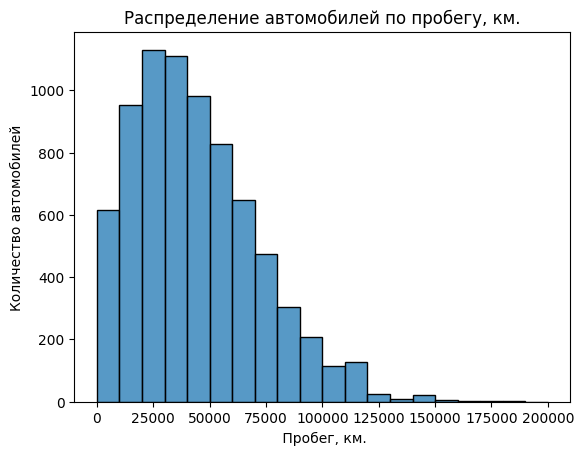

In [48]:
# выделим показатель пробега в числовой форме
df_f['KMS_float'] = df_f['kms_driven'].apply(lambda x: re.findall(r'\d+',x))
df_f['KMS_float'] = df_f['KMS_float'].apply(lambda x: ''.join(x))
df_f['KMS_float'] = df_f['KMS_float'].astype(float)

# фильтр по пробегу ,более 120000 км
df_KMS = df_f.query('KMS_float > 120000')
display("Доля машин с пробегом более 120000 км:",round(df_KMS.shape[0]/df_f.shape[0],4))

# построим гистограмму
sns.histplot(data = df_f, x = 'KMS_float', binwidth=10000, binrange=(0,200001))
plt.title('Распределение автомобилей по пробегу, км.')
plt.xlabel(' Пробег, км.')
plt.ylabel('Количество автомобилей')

Обновляемость модельного ряда

In [51]:
# Создаем множества моделей по годам
df_set_2021 = set(df_f.query('prod_year <= 2021')['model_name'])
df_set_22_23 = set(df_f.query('prod_year >= 2022')['model_name'])
# Находим разницу между множествами
set_diff1 = df_set_22_23.difference(df_set_2021)  # новые модели 2022-2023
set_diff2 = df_set_2021.difference(df_set_22_23)  # модели 2021, которых нет в 2022-2023
print ('Разница в количестве моделей 2022-2023 с 2021:',len(set_diff1))

Разница в количестве моделей 2022-2023 с 2021: 246


Индекс качества авто

In [52]:
# меняем тип столбца на строку
df_f['max_power'] = df_f['max_power'].astype('str')

# извлекаем числовые значения
df_f['max_power_float'] = (df_f['max_power'].apply(lambda x: (re.findall(r'\d+', x))))

# преобразуем в строку
df_f['max_power_float'] = (df_f['max_power_float'].apply(lambda x: '.'.join(x)))

# меняем тип переменной столбца
df_f['max_power_float'] = df_f['max_power_float'].astype('float')

# считаем индекс
df_f['qual_index'] = np.log2(df_f['resale_price_rub'])*np.sqrt(df_f['max_power_float'])/np.log2((df_f['KMS_float']/100))

In [53]:
# определяем границы (квартили) для оценки качества авто
q1 = df_f['qual_index'].quantile(0.25)
q3 = df_f['qual_index'].quantile(0.75)
print(f"q1 = {q1}, q3 = {q3}")

q1 = 20.383798652058697, q3 = 28.76667752424742


In [54]:
# напишем функцию для определения категории авто
def quality_cat(index):
    if index >= q3:
        return 'отличный'
    elif q1 <= index < q3:
        return 'хороший'
    else:
        return 'плохой'

In [55]:
# на основании индекс определяем категорию качества
df_f['qual_cat'] = df_f['qual_index'].apply(lambda index: quality_cat(index))

In [56]:
# Посчитаем количество автомобилей в каждой категории
display(df_f['qual_cat'].value_counts())
display(len(df_f['qual_cat']))

,count
qual_cat,
хороший,3784
плохой,1893
отличный,1893


7570

Text(0, 0.5, 'Количество автомобилей')

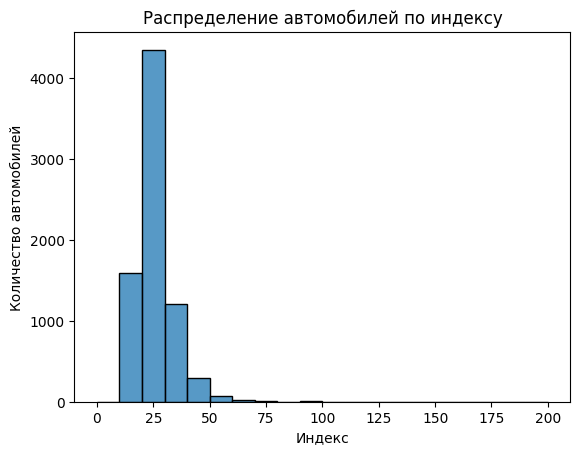

In [57]:
# график распределения по индексу
sns.histplot(data = df_f, x = 'qual_index', binwidth=10, binrange=(0,200))
plt.title('Распределение автомобилей по индексу')
plt.xlabel('Индекс качества')
plt.ylabel('Количество автомобилей')

In [58]:
agg_cols = {
    "resale_price_rub": ["count", "min", "mean", "max"]
}
g = df_f.groupby("qual_cat", as_index=True).agg(agg_cols).round(0)
# Удобные имена столбцов
g.columns = ["Количество", "Мин.", "Ср. знач.", "Макс."]
g

,Количество,Мин.,Ср. знач.,Макс.
qual_cat,,,,
отличный,1893,504600.00,3184259.00,26100000.00
плохой,1893,258680.00,685431.00,3886000.00
хороший,3784,366560.00,1046978.00,7279000.00


#### Далее сосредоточимся на автомобилях категорий хорошо и отлично

In [59]:
df_f_good_n_perfect = df_f[(df_f['qual_cat'] == 'хороший') | (df_f['qual_cat'] == 'отличный')]

In [60]:
agg_cols = {
    "resale_price_rub": ["count", "min", "mean", "max"]
}
g = df_f_good_n_perfect.groupby("qual_cat", as_index=True).agg(agg_cols).round(0)

# Удобные имена столбцов
g.columns = ["Количество", "Мин.", "Ср. знач.", "Макс."]
g

,Количество,Мин.,Ср. знач.,Макс.
qual_cat,,,,
отличный,1893,504600.00,3184259.00,26100000.00
хороший,3784,366560.00,1046978.00,7279000.00


#### Результат работы

In [76]:
pivot = pd.pivot_table(
    df_f_good_n_perfect,
    index=['qual_cat','brand_name','body_type', 'fuel_type','transmission_type', "model_name"],
    values='resale_price_rub',
    aggfunc='mean').round(2)
pivot.columns = ["Средняя цена, руб"]
display(pivot)

Средняя цена, руб
qual_cat brand_name body_type fuel_type transmission_type model_name                                            
отличный Audi       Coupe     Petrol    Automatic         Audi RS5 Sportback BSVI                    11008400.00
                    SUV       Diesel    Automatic         Audi Q3 30 TDI Premium FWD                  3683000.00
                                                          Audi Q3 35 TDI Quattro Premium              2175000.00
                                                          Audi Q3 35 TDI Quattro Premium Plus         2593760.00
                                                          Audi Q3 35 TDI Quattro Technology           2778200.00
...                                                                                                          ...
хороший  Volkswagen Sedan     Petrol    Manual            Volkswagen Vento 1.6 Highline                805813.33
                                                          Volkswagen Vento 1.6 Highline BSIV          1009200.00
                                                          Volkswagen Vento 1.6 Highline Plus           725000.00
                                                          Volkswagen Vento 1.6 MPI ALL STAR            986000.00
         Volvo      Hatchback Diesel    Automatic         Volvo V40 D3 R Design                       2086840.00

[1888 rows x 1 columns]